# Business Understanding

## Project Domain

Dataset Iris digunakan di R.A. Makalah klasik Fisher tahun 1936, Penggunaan Berbagai Pengukuran dalam Masalah Taksonomi, dan juga dapat ditemukan di Repositori Pembelajaran Mesin UCI.

Ini mencakup tiga spesies iris dengan masing-masing 50 sampel serta beberapa properti tentang setiap bunga. Satu spesies bunga dapat dipisahkan secara linier dari dua spesies lainnya, namun dua spesies lainnya tidak dapat dipisahkan secara linier satu sama lain.

## Problem Statements

1. Klasifikasi Spesies Bunga Iris:
  * Dapatkah kita membangun model pembelajaran mesin yang mampu memprediksi spesies bunga Iris (Setosa, Versicolor, Virginica) berdasarkan panjang dan lebar sepal serta petal

2. Analisis Fitur Penting:
  * Fitur mana yang paling berpengaruh dalam membedakan ketiga spesies bunga Iris

3. Pengelompokan (Clustering) Spesies Iris:
  * Bisakah kita mengelompokkan bunga Iris ke dalam tiga klaster berbeda tanpa mengetahui label spesiesnya (unsupervised learning)

4. Evaluasi Model Klasifikasi:
  * Model klasifikasi mana (misalnya K-NN, Decision Tree, SVM) yang memberikan performa terbaik dalam mengklasifikasi spesies bunga Iris

## Goals

Membangun aplikasi ini dapat beberapa manfaat yaitu:
1. Memahami struktur dan karakteristik data bunga Iris
2. Melakukan visualisasi data untuk analisis eksploratif
3. Membangun model klasifikasi
4. Mengevaluasi performa model

## Solustion Statements

1. Pra-pemrosesan Data
Membersihkan dan menyiapkan data dengan memastikan tidak ada nilai kosong atau anomali, serta melakukan normalisasi jika diperlukan.

2. Analisis Eksploratif Data (EDA)
Mengeksplorasi distribusi dan korelasi fitur menggunakan visualisasi seperti scatter plot, pair plot, dan heatmap untuk memahami pola dalam data.

3. Pemilihan Fitur dan Engineering
Menentukan fitur-fitur yang paling relevan melalui analisis korelasi dan importance score dari model.

# Data Understanding

## Import Data dari Kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dickyadryanmaulana","key":"90082d667a0d095d96538a3eb937dfe1"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [ ]:
!kaggle datasets download -d uciml/iris

Dataset URL: https://www.kaggle.com/datasets/uciml/iris
License(s): CC0-1.0


In [ ]:
!mkdir iris
!unzip iris.zip -d iris
!ls iris

Archive:  iris.zip
  inflating: iris/Iris.csv           
  inflating: iris/database.sqlite    
database.sqlite  Iris.csv


## Import Library yang dibutuhkan

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

## Exploratory Data Analysis

In [ ]:
df = pd.read_csv('iris/Iris.csv')

In [ ]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


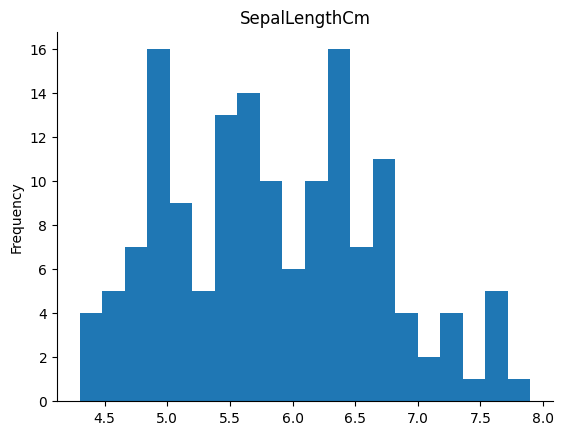

In [ ]:
#SepalLengthCm

from matplotlib import pyplot as plt
df['SepalLengthCm'].plot(kind='hist', bins=20, title='SepalLengthCm')
plt.gca().spines[['top', 'right',]].set_visible(False)

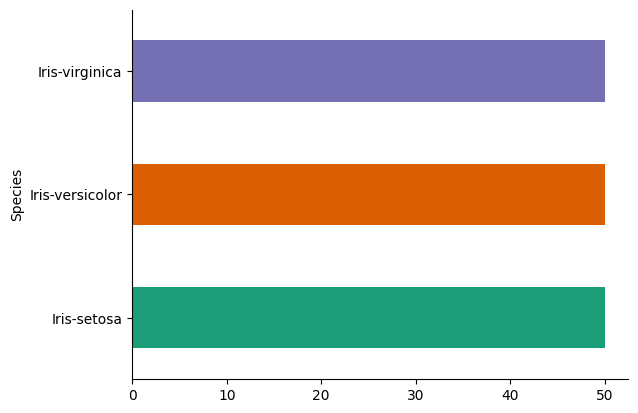

In [ ]:
#Species

from matplotlib import pyplot as plt
import seaborn as sns
df.groupby('Species').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

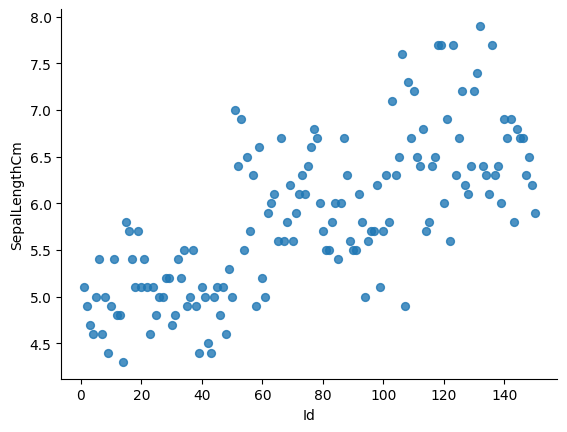

In [ ]:
#SepalLengthCm

from matplotlib import pyplot as plt
df.plot(kind='scatter', x='Id', y='SepalLengthCm', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

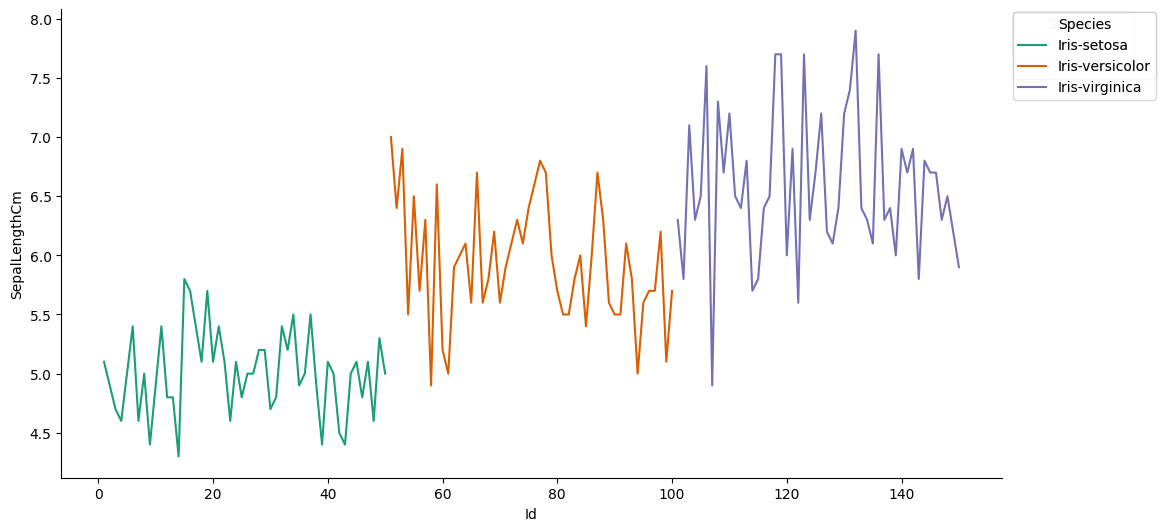

In [ ]:
#Id vs SepalLengthCm

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Id']
  ys = series['SepalLengthCm']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('Id', ascending=True)
for i, (series_name, series) in enumerate(df_sorted.groupby('Species')):
  _plot_series(series, series_name, i)
  fig.legend(title='Species', bbox_to_anchor=(1, 1), loc='upper left')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Id')
_ = plt.ylabel('SepalLengthCm')

<ipython-input-46-984c97eef2d3>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df, x='Id', y='Species', inner='stick', palette='Dark2')


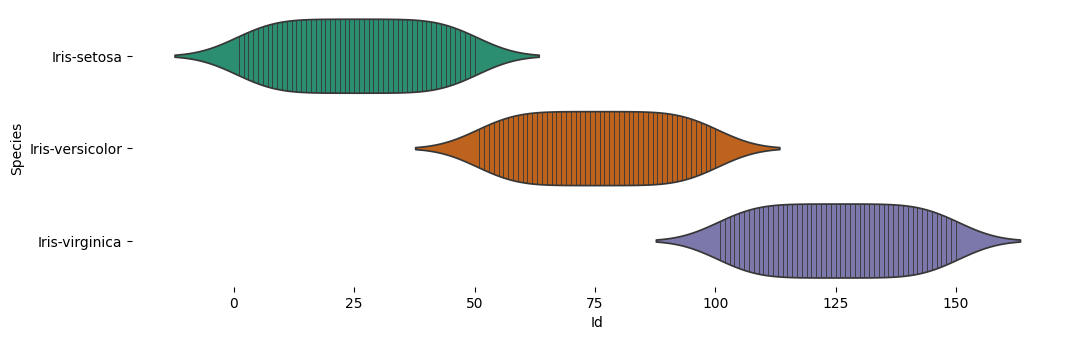

In [ ]:
#Species vs Id

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df['Species'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df, x='Id', y='Species', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


# Data Preparation

In [ ]:
# pisahkan fitur dan target
X = df.drop(columns=["Species","Id"])
y = df["Species"]

In [ ]:
# Encode label target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [ ]:
# Normalisasi fitur
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Bagi data menjadi train dan test set
X_train, X_test, y_train, y_test = train_test_split(X_scaled,
                                                    y_encoded,
                                                    test_size=0.2,
                                                    random_state=42)

# Modeling

In [ ]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(len(le.classes_), activation="softmax")
])

In [ ]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,075 (43.26 KB)

 Trainable params: 11,075 (43.26 KB)

 Non-trainable params: 0 (0.00 B)

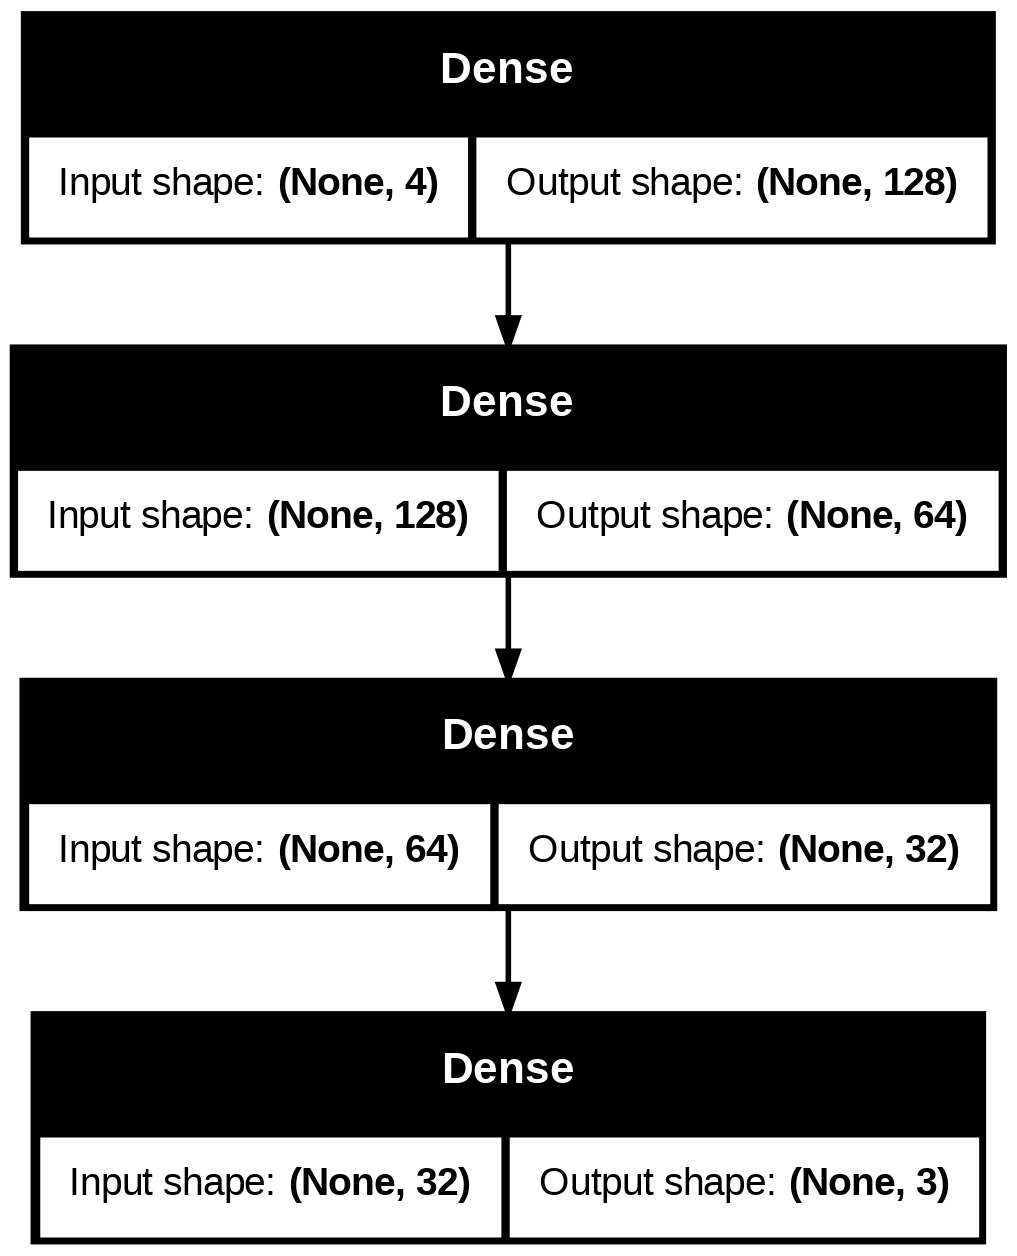

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [ ]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_data=(X_test, y_test))

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.3673 - loss: 1.1214 - val_accuracy: 0.7000 - val_loss: 1.0224
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6218 - loss: 1.0087 - val_accuracy: 0.7000 - val_loss: 0.9321
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6235 - loss: 0.9247 - val_accuracy: 0.7000 - val_loss: 0.8352
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6467 - loss: 0.8296 - val_accuracy: 0.7000 - val_loss: 0.7303
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6821 - loss: 0.7152 - val_accuracy: 0.7000 - val_loss: 0.6248
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7099 - loss: 0.5917 - val_accuracy: 0.7333 - val_loss: 0.5390
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7501 - loss: 0.5351 - val_accuracy: 0.7667 - val_loss: 0.4685
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8246 - loss: 0.4756 - val_accuracy: 0.8333 - val_loss: 0.4146


# Evaluation

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9667 - loss: 0.0851
Akurasi Model: 0.9667
Loss Model: 0.0851


In [ ]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

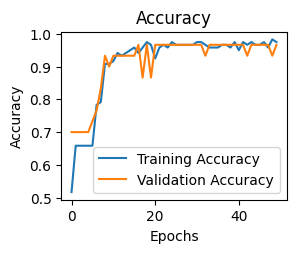

In [ ]:
plt.subplot(2, 2, 4)
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

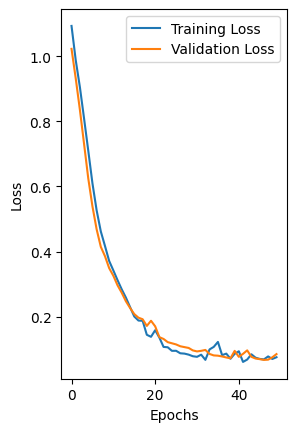

In [ ]:
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


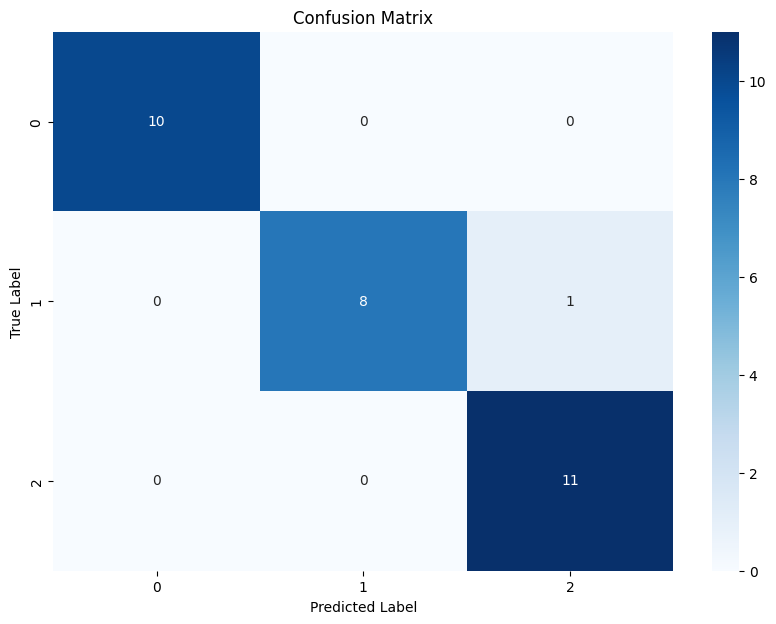

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30



In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [ ]:
sample_input = np.array([[9, 9 ,9, 4]])
sample_input_df = pd.DataFrame(sample_input)

In [ ]:
sample_input_scaled = scaler.transform(sample_input_df)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [ ]:
predicted_class = np.argmax(model.predict(sample_input_scaled))
predicted_crop = le.inverse_transform([predicted_class])

print(f"Iris species: {predicted_crop[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Iris species: Iris-versicolor


## Save Model

In [ ]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('iris.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpfyr7i1ce'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136586641561488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136586641562640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136586641560912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136586641555536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136586641563216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136586641559568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136586641563600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136586641562448: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [ ]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']